In [15]:
## Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import pathlib
import json
from PIL import Image
from tensorflow.keras.layers import Conv2D, BatchNormalization, Dense,Input
from tensorflow.keras import Sequential
from pathlib import Path

## Loading Images from dir
image_dir='Normal_Images'
image_files_raw=sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg','jpeg', '.png', '.bmp'))])

image_files_full_path=[]
for i in image_files_raw:
    image_files_full_path.append(image_dir+'\\'+i)

## Reading Images
images=[]
for i in image_files_full_path:
    images.append(cv2.imread(str(i)))

## Printing length of images
print(f'No. of Images: {len(images)}')

## Downsampling from 416 to 320
resized_images=[]
size=[(320,320)]
for img in images:
    #print(np.array(img))
    resized_images.append(cv2.resize(img,(320,320)))


No. of Images: 226


In [16]:
resized_images[0]

array([[[167, 119,  31],
        [168, 120,  32],
        [167, 117,  33],
        ...,
        [168, 115,  35],
        [168, 115,  35],
        [168, 115,  35]],

       [[167, 119,  31],
        [168, 120,  32],
        [167, 117,  33],
        ...,
        [168, 115,  35],
        [168, 115,  35],
        [168, 115,  35]],

       [[167, 119,  31],
        [168, 120,  32],
        [167, 117,  34],
        ...,
        [168, 115,  35],
        [168, 115,  35],
        [168, 115,  35]],

       ...,

       [[176, 120,  39],
        [176, 120,  39],
        [176, 120,  39],
        ...,
        [175, 119,  38],
        [175, 119,  38],
        [175, 119,  38]],

       [[176, 120,  39],
        [176, 120,  39],
        [176, 120,  39],
        ...,
        [175, 119,  38],
        [175, 119,  38],
        [175, 119,  38]],

       [[176, 120,  39],
        [176, 120,  39],
        [176, 120,  39],
        ...,
        [175, 119,  38],
        [175, 119,  38],
        [175, 119,  38]]

In [17]:

## Normalie images
for i in range(len(resized_images)):
    resized_images[i]=np.round(resized_images[i]/255.0,2)


In [18]:
resized_images[0]

array([[[0.65, 0.47, 0.12],
        [0.66, 0.47, 0.13],
        [0.65, 0.46, 0.13],
        ...,
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14]],

       [[0.65, 0.47, 0.12],
        [0.66, 0.47, 0.13],
        [0.65, 0.46, 0.13],
        ...,
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14]],

       [[0.65, 0.47, 0.12],
        [0.66, 0.47, 0.13],
        [0.65, 0.46, 0.13],
        ...,
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14]],

       ...,

       [[0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        ...,
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15]],

       [[0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        ...,
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15]],

       [[0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0

In [20]:

## Train Test Split X
train_images=resized_images[:int(len(resized_images)*0.8)]
test_images=resized_images[int(len(resized_images)*0.8):]

In [21]:
train_images[0]

array([[[0.65, 0.47, 0.12],
        [0.66, 0.47, 0.13],
        [0.65, 0.46, 0.13],
        ...,
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14]],

       [[0.65, 0.47, 0.12],
        [0.66, 0.47, 0.13],
        [0.65, 0.46, 0.13],
        ...,
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14]],

       [[0.65, 0.47, 0.12],
        [0.66, 0.47, 0.13],
        [0.65, 0.46, 0.13],
        ...,
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14]],

       ...,

       [[0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        ...,
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15]],

       [[0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        ...,
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15]],

       [[0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0

In [22]:
test_images[0]

array([[[0.11, 0.3 , 0.21],
        [0.11, 0.3 , 0.21],
        [0.11, 0.3 , 0.21],
        ...,
        [0.14, 0.22, 0.21],
        [0.14, 0.22, 0.21],
        [0.14, 0.22, 0.21]],

       [[0.11, 0.3 , 0.21],
        [0.11, 0.3 , 0.21],
        [0.12, 0.31, 0.21],
        ...,
        [0.14, 0.22, 0.21],
        [0.14, 0.22, 0.21],
        [0.14, 0.22, 0.21]],

       [[0.11, 0.3 , 0.21],
        [0.12, 0.31, 0.21],
        [0.12, 0.31, 0.21],
        ...,
        [0.15, 0.23, 0.22],
        [0.15, 0.23, 0.21],
        [0.14, 0.22, 0.21]],

       ...,

       [[0.52, 0.54, 0.54],
        [0.33, 0.37, 0.35],
        [0.13, 0.19, 0.14],
        ...,
        [0.2 , 0.29, 0.23],
        [0.2 , 0.29, 0.23],
        [0.2 , 0.29, 0.23]],

       [[0.49, 0.52, 0.51],
        [0.25, 0.29, 0.26],
        [0.1 , 0.17, 0.12],
        ...,
        [0.22, 0.3 , 0.24],
        [0.21, 0.29, 0.23],
        [0.2 , 0.28, 0.22]],

       [[0.47, 0.5 , 0.47],
        [0.19, 0.24, 0.2 ],
        [0.07, 0

In [23]:
## Generating y_true (greyscale)
grey_images=[]
for image in resized_images:
    column=[]
    for i in range(image.shape[0]):
        row=[]
        for j in range(image.shape[1]):
            #print(np.mean(array_orig[i,j,:]))
            grey_pixel=np.mean(image[i,j,:])
            row.append(grey_pixel)
        column.append(row)
        
    grey_images.append(column)


In [24]:
## Train Test split Y
y_train=grey_images[:int(len(resized_images)*0.8)]
y_test=grey_images[int(len(resized_images)*0.8):]

## To numpy array
train_images=np.array(train_images)
test_images=np.array(test_images)
y_train=np.array(y_train)
y_test=np.array(y_test)

## Tensor shapes
print(f'Train Images Shape: {train_images.shape}')
print(f'Y Train Images Shape: {y_train.shape}')
print(f'Test Images Shape: {test_images.shape}')
print(f'Y Test Images Shape: {y_test.shape}')

Train Images Shape: (180, 320, 320, 3)
Y Train Images Shape: (180, 320, 320)
Test Images Shape: (46, 320, 320, 3)
Y Test Images Shape: (46, 320, 320)


In [25]:
y_train[0]

array([[0.41333333, 0.42      , 0.41333333, ..., 0.41666667, 0.41666667,
        0.41666667],
       [0.41333333, 0.42      , 0.41333333, ..., 0.41666667, 0.41666667,
        0.41666667],
       [0.41333333, 0.42      , 0.41333333, ..., 0.41666667, 0.41666667,
        0.41666667],
       ...,
       [0.43666667, 0.43666667, 0.43666667, ..., 0.43666667, 0.43666667,
        0.43666667],
       [0.43666667, 0.43666667, 0.43666667, ..., 0.43666667, 0.43666667,
        0.43666667],
       [0.43666667, 0.43666667, 0.43666667, ..., 0.43666667, 0.43666667,
        0.43666667]])

In [26]:
resized_images[0]

array([[[0.65, 0.47, 0.12],
        [0.66, 0.47, 0.13],
        [0.65, 0.46, 0.13],
        ...,
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14]],

       [[0.65, 0.47, 0.12],
        [0.66, 0.47, 0.13],
        [0.65, 0.46, 0.13],
        ...,
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14]],

       [[0.65, 0.47, 0.12],
        [0.66, 0.47, 0.13],
        [0.65, 0.46, 0.13],
        ...,
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14],
        [0.66, 0.45, 0.14]],

       ...,

       [[0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        ...,
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15]],

       [[0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        ...,
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15]],

       [[0.69, 0.47, 0.15],
        [0.69, 0.47, 0.15],
        [0.69, 0

c:\Users\HP\.pyenv\pyenv-win\versions\3.9.13\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 320, 320, 1)    │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0749 - mse: 0.0106 - val_loss: 0.0495 - val_mse: 0.0055
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0614 - mse: 0.0093 - val_loss: 0.0467 - val_mse: 0.0052
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0581 - mse: 0.0089 - val_loss: 0.0439 - val_mse: 0.0048
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0504 - mse: 0.0068 - val_loss: 0.0436 - val_mse: 0.0047
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0551 - mse: 0.0085 - val_loss: 0.0418 - val_mse: 0.0044
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0500 - mse: 0.0070 - val_loss: 0.0407 - val_mse: 0.0042
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0479 - mse: 0.0063 - val_loss: 0.0391 - val_mse: 0.0039
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0467 - mse: 0.0061 - val_loss: 0.0381 - val_mse: 0.0037
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - l

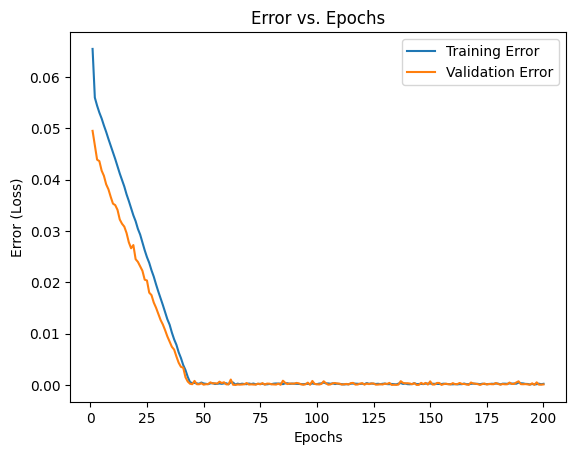

In [27]:
## One convolution approach
input_shape=(320,320,3)

## Model Architecture
model=Sequential([
    Conv2D(1,1,input_shape=(320,320,3),activation='relu')
])

## Model Summary
print(model.summary())

## Selecting Optimiser and Learning Rate=0.1
from tensorflow.keras.optimizers import Adam
optimizer=Adam(learning_rate=0.1)

## Model Compilation
model.compile(optimizer='adam',loss='mae',metrics=['mse'])

## Training on 200 Epochs
history = model.fit(train_images, y_train, validation_data=(test_images, y_test), epochs=200, batch_size=4)


## Extract loss data
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

## Viisualise loss with epochs
plt.plot(epochs, train_loss , label='Training Error')
plt.plot(epochs, val_loss, label='Validation Error')
plt.title('Error vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Error (Loss)')
plt.legend()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


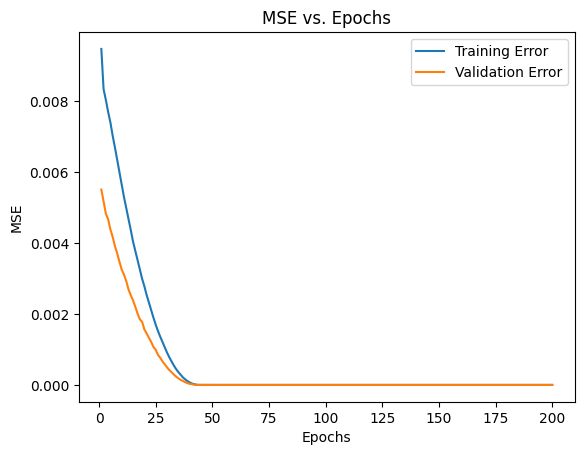

In [28]:

## Extract metrics data
train_loss = history.history['mse']
val_loss = history.history['val_mse']
epochs = range(1, len(train_loss) + 1)

#3 Create metrics plot
plt.plot(epochs, train_loss , label='Training Error')
plt.plot(epochs, val_loss, label='Validation Error')
plt.title('MSE vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

## Prediction
pred_images=model.predict(test_images)
pred_images.shape

## Converting back to 0-255 levels
pred_images=pred_images*255.0
pred_images=pred_images.astype(int)

## Converting test images back to 0-255 levels
y_test_full=y_test*255.0
y_test_full=y_test_full.astype(int)

## Original Image
Image.fromarray(y_test_full[0].astype(np.uint8)).show()

## Predicted Image
Image.fromarray(np.squeeze(pred_images[0]).astype(np.uint8)).show()

## Saving Model
model.save('Grey.h5')

In [70]:


## Loading Images from dir
image_dir='dip'
image_files_raw=sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg','jpeg', '.png', '.bmp'))])

image_files_full_path=[]
for i in image_files_raw:
    image_files_full_path.append(image_dir+'\\'+i)

## Reading Images
images=[]
for i in image_files_full_path:
    images.append(cv2.imread(str(i)))

## Printing length of images
print(f'No. of Images: {len(images)}')

## Downsampling from 416 to 320
resized_val_images=[]
size=[(320,320)]
for img in images:
    #print(np.array(img))
    resized_val_images.append(cv2.resize(img,(320,320)))


No. of Images: 29


In [71]:
temp=resized_val_images.copy()

In [72]:

## Normalie images
for i in range(len(resized_val_images)):
    resized_val_images[i]=np.round(resized_val_images[i]/255.0,2)




In [73]:
resized_val_images=np.array(resized_val_images)

In [74]:
## Prediction
pred_images=model.predict(resized_val_images)
pred_images.shape

## Converting back to 0-255 levels
pred_images=pred_images*255.0
pred_images=pred_images.astype(int)

## Converting test images back to 0-255 levels
resized_val_images=resized_val_images*255.0
resized_val_images=resized_val_images.astype(int)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [75]:
temp[5]

array([[[210, 197, 190],
        [247, 235, 226],
        [236, 227, 212],
        ...,
        [124, 122,  98],
        [115, 113,  89],
        [101,  99,  75]],

       [[240, 237, 222],
        [198, 193, 176],
        [199, 194, 174],
        ...,
        [111, 109,  85],
        [110, 108,  83],
        [109, 107,  83]],

       [[174, 176, 154],
        [191, 194, 170],
        [224, 228, 203],
        ...,
        [123, 121,  97],
        [107, 105,  81],
        [110, 108,  84]],

       ...,

       [[177, 186, 215],
        [179, 189, 220],
        [199, 211, 245],
        ...,
        [147, 190, 241],
        [138, 181, 232],
        [141, 184, 236]],

       [[167, 166, 187],
        [179, 178, 200],
        [168, 168, 193],
        ...,
        [153, 195, 245],
        [143, 185, 235],
        [144, 187, 238]],

       [[129, 116, 133],
        [129, 116, 134],
        [130, 118, 136],
        ...,
        [136, 177, 226],
        [131, 172, 221],
        [140, 183, 234]]

In [105]:
## Original Image
#Image.fromarray(temp[5].astype(np.uint8)).show()

## Predicted Image
Image.fromarray(np.squeeze(pred_images[5]).astype(np.uint8)).show()
i=Image.fromarray(np.squeeze(pred_images[5]).astype(np.uint8))
i.save('grey predicted.png')